In [15]:
!nvidia-smi

Sun May  3 12:25:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
!pip install ultralytics roboflow


In [17]:
from ultralytics import YOLO
from roboflow import Roboflow


In [31]:
from google.colab import userdata
from roboflow import Roboflow

API_KEY = userdata.get("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=API_KEY)

project = rf.workspace("learning-evidence").project("helmet-detection_yolov8")
version = project.version(3)

dataset = version.download("yolov8")

print("Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /content/Helmet-Detection_YOLOv8-3


In [18]:
import os

dataset_path = "/content/Helmet-Detection_YOLOv8-3"

print("Files/folders inside dataset:")
print(os.listdir(dataset_path))

print("\nTrain folder:")
print(os.listdir(os.path.join(dataset_path, "train")))

Files/folders inside dataset:
['README.roboflow.txt', 'test', 'train', 'valid', 'README.dataset.txt', 'data.yaml']

Train folder:
['labels', 'images']


In [19]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/Helmet-Detection_YOLOv8-3/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    name="helmet_detection_yolov8"
)


Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Helmet-Detection_YOLOv8-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_detection_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

In [20]:
from ultralytics import YOLO

best_model_path = "/content/runs/detect/helmet_detection_yolov8/weights/best.pt"

model = YOLO(best_model_path)

metrics = model.val(
    data="/content/Helmet-Detection_YOLOv8-3/data.yaml"
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1809.3±1060.2 MB/s, size: 67.3 KB)
val: Scanning /content/Helmet-Detection_YOLOv8-3/valid/labels.cache... 372 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 372/372 120.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.6it/s 9.4s
                   all        372        660      0.855      0.907      0.931      0.583
           With Helmet        215        338      0.881      0.926      0.949      0.644
        Without Helmet        208        322      0.829      0.888      0.914      0.522
Speed: 3.9ms preprocess, 5.2ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to /content/runs/detect/val


In [21]:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Precision: 0.855041659238645
Recall: 0.9071171303612775
mAP50: 0.9311809346765352
mAP50-95: 0.5829853989680058


In [22]:
from ultralytics import YOLO
print("YOLO imported again")

YOLO imported again


In [23]:
import os

best_model_path = "/content/runs/detect/helmet_detection_yolov8/weights/best.pt"

print(os.path.exists(best_model_path))

True


In [24]:
from ultralytics import YOLO

best_model_path = "/content/runs/detect/helmet_detection_yolov8/weights/best.pt"
model = YOLO(best_model_path)

results = model.predict(
    source="/content/Helmet-Detection_YOLOv8-3/test/images",
    conf=0.25,
    save=True,
    name="helmet_test_predictions"
)



image 1/149 /content/Helmet-Detection_YOLOv8-3/test/images/BikesHelmets102_png.rf.b771e83db4052e5e48900f1d9f4ee68e.jpg: 640x640 2 With Helmets, 45.8ms
image 2/149 /content/Helmet-Detection_YOLOv8-3/test/images/BikesHelmets110_png.rf.108cd2cfde7b038eea459b97539f7922.jpg: 640x640 1 With Helmet, 8 Without Helmets, 52.4ms
image 3/149 /content/Helmet-Detection_YOLOv8-3/test/images/BikesHelmets113_png.rf.ce74cc3e9c8d03be417b6cd16444261e.jpg: 640x640 1 With Helmet, 1 Without Helmet, 51.3ms
image 4/149 /content/Helmet-Detection_YOLOv8-3/test/images/BikesHelmets143_png.rf.caf0aacf12adfbfa16b20b8c3563a803.jpg: 640x640 7 Without Helmets, 51.7ms
image 5/149 /content/Helmet-Detection_YOLOv8-3/test/images/BikesHelmets158_png.rf.71cdb3536b840ccc2f0e44d1e5ce36e3.jpg: 640x640 1 With Helmet, 49.4ms
image 6/149 /content/Helmet-Detection_YOLOv8-3/test/images/BikesHelmets183_png.rf.1f9ebed2be11011e589ec58d1def89c1.jpg: 640x640 1 With Helmet, 59.6ms
image 7/149 /content/Helmet-Detection_YOLOv8-3/test/image

In [25]:
import os

pred_path = "/content/runs/detect/helmet_test_predictions"

print(os.listdir(pred_path)[:10])
print("Total prediction files:", len(os.listdir(pred_path)))

['train479_jpg.rf.9d2a541f6d21eeada6fdee95cc11690e.jpg', 'test16_jpg.rf.d10e44bdf0099562590be3254b0d7f26.jpg', 'BikesHelmets559_png.rf.80301487197c7f94dce0f59d3a66adb0.jpg', 'train64_jpg.rf.2100aaeb77678952839009633f5e372d.jpg', 'train661_jpg.rf.5741ceb9670f7d06b50d163aa7e05ebf.jpg', 'val65_jpg.rf.dac5d9d08900b979300bfc75f6a91202.jpg', 'BikesHelmets449_png.rf.183125c7fb376ba3ee639f3728cd7cb8.jpg', 'val67_jpg.rf.3c3d0a00ea20e06bd29018fab5e492aa.jpg', 'BikesHelmets30_png.rf.d7b5ff447118e97fbb2f4f01ab442108.jpg', 'train150_jpg.rf.181ee1e09bd5ab55ef7878c0dae4b739.jpg']
Total prediction files: 149


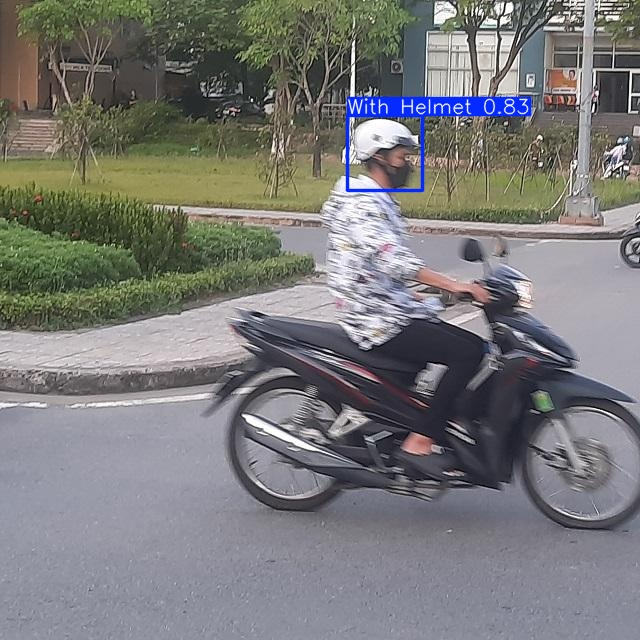

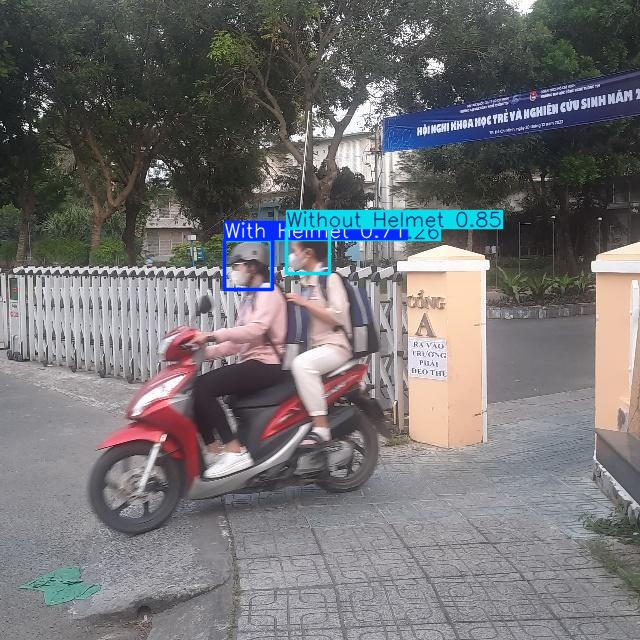

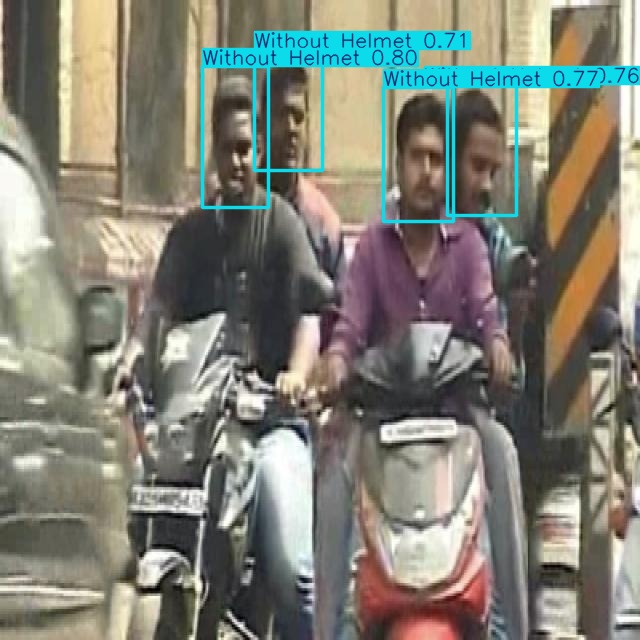

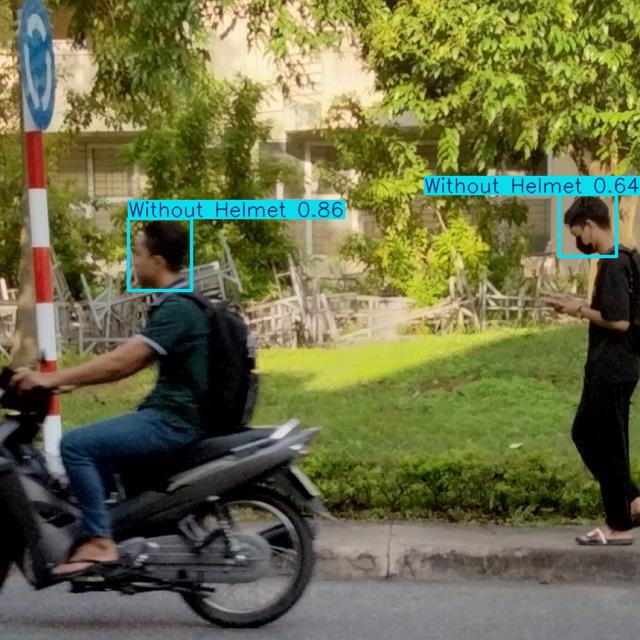

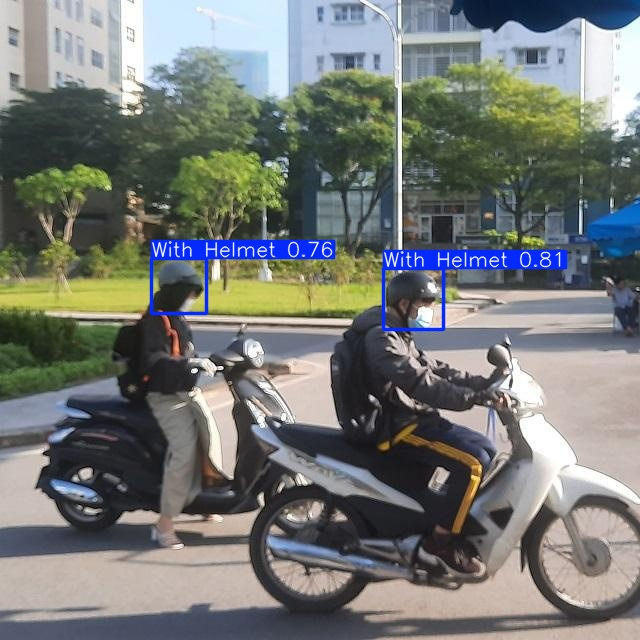

In [26]:
import glob
from IPython.display import Image, display

pred_path = "/content/runs/detect/helmet_test_predictions"

sample_images = glob.glob(pred_path + "/*.jpg")[:5]

for img_path in sample_images:
    display(Image(filename=img_path, width=500))

In [27]:
import shutil
import os

source_folder = "/content/runs/detect/helmet_detection_yolov8"
output_zip = "/content/helmet_detection_training_results"

shutil.make_archive(output_zip, "zip", source_folder)

print("Created zip file:", output_zip + ".zip")

Created zip file: /content/helmet_detection_training_results.zip


In [28]:
source_folder = "/content/runs/detect/helmet_test_predictions"
output_zip = "/content/helmet_detection_predictions"

shutil.make_archive(output_zip, "zip", source_folder)

print("Created zip file:", output_zip + ".zip")

Created zip file: /content/helmet_detection_predictions.zip


In [29]:
from google.colab import files

files.download("/content/helmet_detection_training_results.zip")
files.download("/content/helmet_detection_predictions.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>